<a href="https://colab.research.google.com/github/helomelo1/basket-trading-using-bayesian-optimization/blob/main/pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import pandas as pd
import yfinance as yf
import requests
import matplotlib.pyplot as plt

from bayesian_optimization import bayesian_optimize

In [2]:
def run_strategy(prices, returns, window, basket):

    momentum = prices.shift(21).pct_change(window)
    dates = returns.index[window+1:]

    portfolio_returns = []

    for date in dates:

        prev_date = prices.index[prices.index.get_loc(date)-1]
        mom = momentum.loc[prev_date]
        top_assets = mom.nlargest(basket).index
        daily_return = returns.loc[date, top_assets].mean()

        portfolio_returns.append(daily_return)

    portfolio_returns = pd.Series(portfolio_returns)
    sharpe = portfolio_returns.mean() / portfolio_returns.std() * np.sqrt(252)

    return sharpe

In [15]:
def get_strategy_returns(prices, returns, window, basket):

    momentum = prices.shift(21).pct_change(window)

    dates = returns.index[window+1:]

    portfolio_returns = []

    for date in dates:

        prev_date = prices.index[prices.index.get_loc(date)-1]

        mom = momentum.loc[prev_date]

        top_assets = mom.nlargest(basket).index

        daily_return = returns.loc[date, top_assets].mean()

        portfolio_returns.append(daily_return)

    strategy_returns = pd.Series(portfolio_returns, index=dates)

    return strategy_returns

In [3]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

table = pd.read_html(response.text)

sp500 = table[0]

tickers = sp500["Symbol"].tolist()

print(len(tickers))

503


/tmp/ipykernel_1002/728355342.py:9: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_html(response.text)


In [4]:
data = yf.download(
tickers,
start="2019-01-01",
end="2026-01-01"
)

/tmp/ipykernel_1002/2848843778.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2019-01-01 -> 2026-01-01)')


In [5]:
prices = data["Close"]
prices = prices.dropna(axis=1)
print("Price shape:", prices.shape)

Price shape: (1760, 476)


In [6]:
returns = prices.pct_change().dropna()
returns.head()

Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-03,-0.036839,-0.099607,-0.032948,-0.047194,-0.015655,-0.034142,-0.039498,-0.060405,-0.004396,-0.030198,...,0.033906,-0.009675,-0.003940,-0.015354,-0.034280,-0.083566,-0.025153,-0.018088,-0.059908,-0.034564
2019-01-04,0.034613,0.042689,0.032217,0.028541,0.023662,0.038884,0.048632,0.024278,0.023056,0.039854,...,0.034142,0.040333,0.009785,0.036870,0.042192,0.109882,0.026027,0.034153,0.041462,0.039235
2019-01-07,0.021234,-0.002226,0.014595,0.014976,-0.002274,0.003473,0.013573,0.006289,0.005035,-0.005410,...,0.019982,0.017757,-0.004330,0.005200,-0.014789,0.043658,-0.001093,0.000385,0.015166,0.006017
2019-01-08,0.014660,0.019063,0.004648,-0.012006,0.003798,0.025290,0.014918,0.024396,0.018607,0.005899,...,0.005963,0.031333,0.011596,0.007271,0.009401,0.039526,-0.001970,-0.022425,0.006697,0.014894
2019-01-09,0.020935,0.016982,-0.032823,0.016691,0.012864,0.005030,0.011819,0.025340,0.008666,0.000914,...,0.003387,0.013020,-0.007983,0.005275,0.016224,0.044518,-0.000439,0.008171,0.024819,-0.003582


In [7]:
train_prices = prices.loc[:'2021-12-31']
test_prices = prices.loc['2022-01-01':]

train_returns = returns.loc[:'2021-12-31']
test_returns = returns.loc['2022-01-01':]

In [8]:
def objective(window, basket):
    return run_strategy(train_prices, train_returns, window, basket)

In [9]:
bounds = [
        (63,252),   # momentum window
        (5,40)      # basket size
    ]

In [10]:
print("Running Bayesian Optimization...")

best_params, best_score = bayesian_optimize(objective, bounds)

best_window = best_params[0]
best_basket = best_params[1]

print("Momentum Window:", best_window)
print("Basket Size:", best_basket)

train_sharpe = run_strategy(train_prices, train_returns, best_window, best_basket)
test_sharpe = run_strategy(test_prices, test_returns, best_window, best_basket)

print("Train Sharpe:", train_sharpe)
print("Test Sharpe:", test_sharpe)

Running Bayesian Optimization...
Momentum Window: 176
Basket Size: 6
Train Sharpe: 1.8050416629745534
Test Sharpe: 1.5419439660457623


In [18]:
strategy_returns = get_strategy_returns(prices, returns, best_window, best_basket)
strategy_returns.head()

,0
Date,
2019-09-17,0.004156
2019-09-18,0.002562
2019-09-19,0.001239
2019-09-20,-0.002195
2019-09-23,0.001587


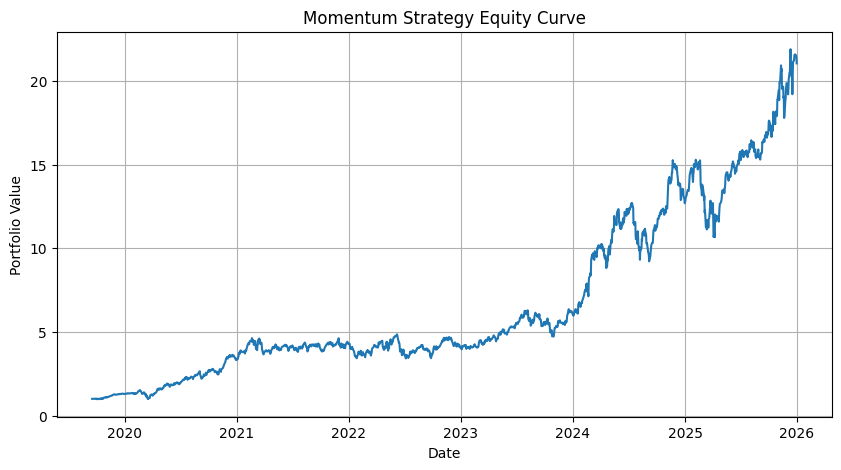

In [20]:
strategy_curve = (1 + strategy_returns).cumprod()
strategy_curve = strategy_curve / strategy_curve.iloc[0]

plt.figure(figsize=(10,5))
plt.plot(strategy_curve)

plt.title("Momentum Strategy Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.grid(True)
plt.show()

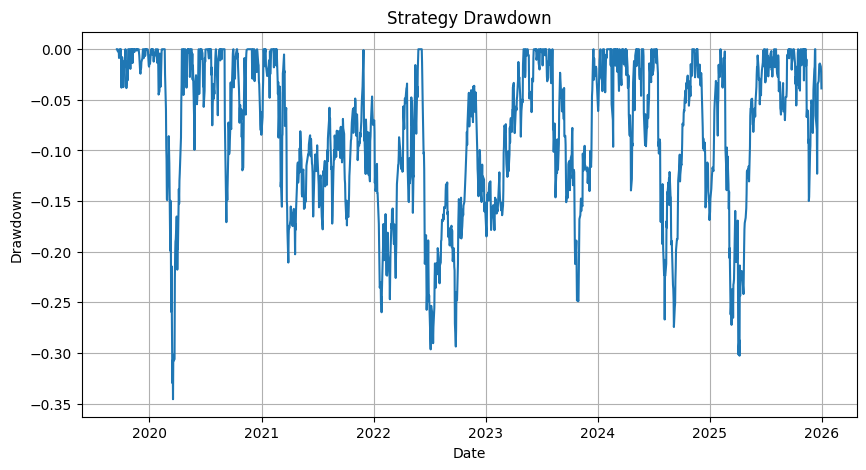

In [21]:
rolling_max = strategy_curve.cummax()

drawdown = strategy_curve / rolling_max - 1

plt.figure(figsize=(10,5))
plt.plot(drawdown)

plt.title("Strategy Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.grid(True)
plt.show()

/tmp/ipykernel_1002/1166921866.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download(
[*********************100%***********************]  1 of 1 completed


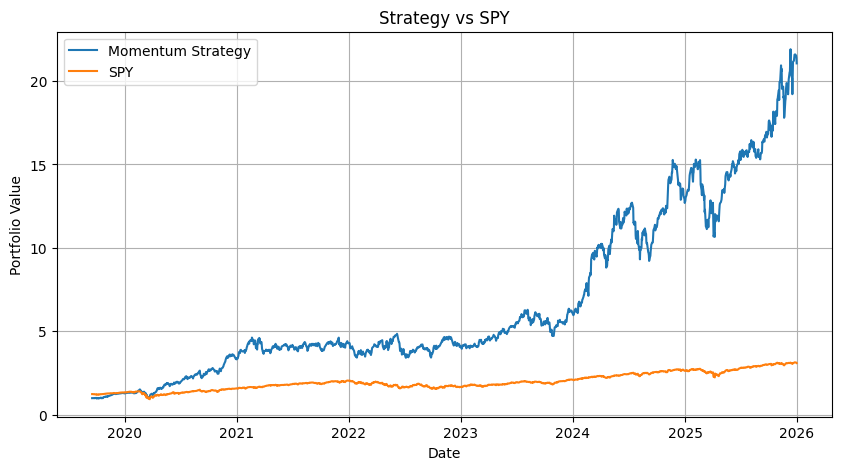

In [23]:
spy = yf.download(
    "SPY",
    start="2019-01-01",
    end="2026-01-01"
)["Close"]

spy_returns = spy.pct_change().dropna()

spy_curve = (1 + spy_returns).cumprod()
spy_curve = spy_curve / spy_curve.iloc[0]

spy_curve = spy_curve.loc[strategy_curve.index]

plt.figure(figsize=(10,5))

plt.plot(strategy_curve, label="Momentum Strategy")
plt.plot(spy_curve, label="SPY")

plt.title("Strategy vs SPY")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.grid(True)
plt.show()

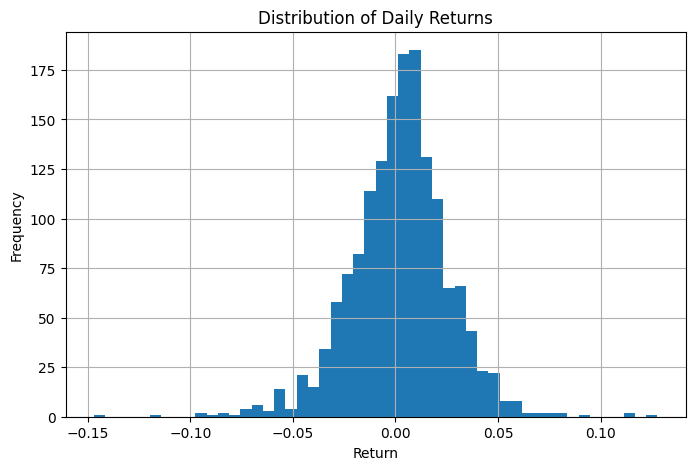

In [24]:
plt.figure(figsize=(8,5))

plt.hist(strategy_returns, bins=50)

plt.title("Distribution of Daily Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()